In [ ]:
import pandas as pd

# 1. Data Loading
# Ensure 'heart_disease_data.csv' is uploaded to your Colab session
df = pd.read_csv('heart_disease_data.csv')

# (a) Display the first 10 observations
print("First 10 observations:")
display(df.head(10))

# (b) Display the last 5 observations
print("\nLast 5 observations:")
display(df.tail(5))

First 10 observations:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0



Last 5 observations:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [ ]:
# 2. Shape of the Dataset
rows, cols = df.shape

print(f"Number of observations (rows): {rows}")
print(f"Number of variables (columns): {cols}")

Number of observations (rows): 918
Number of variables (columns): 12


In [ ]:
import pandas as pd
import numpy as np

# Assuming 'df' is already loaded from previous steps

# 3(a) Check for missing values in each variable
print("--- Missing Values (NaN) ---")
print(df.isnull().sum())

# Note: Check for implicit missing values (e.g., zeros where they shouldn't be)
print("\n--- Implicit Missing Values (Zeros) ---")
print(f"RestingBP == 0: {(df['RestingBP'] == 0).sum()}")
print(f"Cholesterol == 0: {(df['Cholesterol'] == 0).sum()}")

# 3(c) Identify possible outliers using the IQR method
cols_to_check = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
outlier_indices = set()

print("\n--- Outliers Detected (IQR Method) ---")
for col in cols_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    # Filter outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")

    # Store indices to optionally drop them later
    outlier_indices.update(outliers.index)

--- Missing Values (NaN) ---
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

--- Implicit Missing Values (Zeros) ---
RestingBP == 0: 1
Cholesterol == 0: 172

--- Outliers Detected (IQR Method) ---
Age: 0 outliers
RestingBP: 28 outliers
Cholesterol: 183 outliers
MaxHR: 2 outliers
Oldpeak: 16 outliers


In [ ]:
import pandas as pd
import numpy as np

# Load the dataset (assuming it is in the current directory)
df = pd.read_csv('heart_disease_data.csv')
print(f"Original shape: {df.shape}")

# 1. Treatment of Missing Values (Implicit Zeros)
# (a) Drop the single anomalous row where RestingBP is 0
df_cleaned = df[df['RestingBP'] > 0].copy()

# (b) Impute Cholesterol values of 0 with the median of the non-zero cholesterol values
median_cholesterol = df_cleaned.loc[df_cleaned['Cholesterol'] > 0, 'Cholesterol'].median()
df_cleaned.loc[df_cleaned['Cholesterol'] == 0, 'Cholesterol'] = median_cholesterol

# 2. Outlier Retention
# As justified in the previous step, physiological outliers detected via IQR
# (in Age, RestingBP, Cholesterol, MaxHR, Oldpeak) represent genuine clinical
# cardiovascular indicators. Therefore, no filtering is applied to remove them.

# 3. New Shape of the Dataset
new_rows, new_cols = df_cleaned.shape
print(f"New shape after cleaning: ({new_rows}, {new_cols})")

Original shape: (918, 12)
New shape after cleaning: (917, 12)


In [ ]:
cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
stats = []

for col in cols:
    stats.append({
        'Feature': col,
        'Mean': round(df_cleaned[col].mean(), 2),
        'Median': round(df_cleaned[col].median(), 2),
        'Mode': round(df_cleaned[col].mode().iloc[0], 2),
        'Minimum': round(df_cleaned[col].min(), 2),
        'Maximum': round(df_cleaned[col].max(), 2),
        'Std Dev': round(df_cleaned[col].std(), 2),
        'Q1': round(df_cleaned[col].quantile(0.25), 2),
        'Q3': round(df_cleaned[col].quantile(0.75), 2)
    })

stats_df = pd.DataFrame(stats)
display(stats_df)

,Feature,Mean,Median,Mode,Minimum,Maximum,Std Dev,Q1,Q3
0,Age,53.51,54.0,54.0,28.0,77.0,9.44,47.0,60.0
1,RestingBP,132.54,130.0,120.0,80.0,200.0,18.00,120.0,140.0
2,Cholesterol,243.21,237.0,237.0,85.0,603.0,53.43,214.0,267.0
3,MaxHR,136.79,138.0,150.0,60.0,202.0,25.47,120.0,156.0
4,Oldpeak,0.89,0.6,0.0,-2.6,6.2,1.07,0.0,1.5


In [ ]:
# 5(a) Find the median age of patients with HeartDisease = 1
median_age_hd1 = df_cleaned[df_cleaned['HeartDisease'] == 1]['Age'].median()
print(f"Median age of patients with HeartDisease = 1: {median_age_hd1}")

# 5(b) Find the median age of patients with HeartDisease = 0
median_age_hd0 = df_cleaned[df_cleaned['HeartDisease'] == 0]['Age'].median()
print(f"Median age of patients with HeartDisease = 0: {median_age_hd0}")

# 5(c) Percentage of patients with HeartDisease = 1 who are male
hd1_patients = df_cleaned[df_cleaned['HeartDisease'] == 1]
pct_male_hd1 = (hd1_patients['Sex'] == 'M').mean() * 100
print(f"Percentage of HeartDisease = 1 patients who are male: {pct_male_hd1:.2f}%")

# 5(d) Percentage of patients above 50 years of age who have HeartDisease = 1
above_50 = df_cleaned[df_cleaned['Age'] > 50]
pct_hd1_above_50 = (above_50['HeartDisease'] == 1).mean() * 100
print(f"Percentage of patients >50 years old with HeartDisease = 1: {pct_hd1_above_50:.2f}%")

# 5(e) Percentage of patients with HeartDisease = 1 for each ChestPainType
pct_hd1_by_cpt = df_cleaned.groupby('ChestPainType')['HeartDisease'].mean() * 100
print("\nPercentage of patients with HeartDisease = 1 per ChestPainType:")
print(pct_hd1_by_cpt.round(2).astype(str) + '%')

Median age of patients with HeartDisease = 1: 57.0
Median age of patients with HeartDisease = 0: 51.0
Percentage of HeartDisease = 1 patients who are male: 90.14%
Percentage of patients >50 years old with HeartDisease = 1: 63.56%

Percentage of patients with HeartDisease = 1 per ChestPainType:
ChestPainType
ASY    79.03%
ATA    13.87%
NAP    35.15%
TA     43.48%
Name: HeartDisease, dtype: object


In [ ]:
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

for col in categorical_cols:
    # Calculate frequency (count) and percentage
    freq = df_cleaned[col].value_counts()
    pct = df_cleaned[col].value_counts(normalize=True) * 100

    # Combine into a single DataFrame for a clean table presentation
    freq_table = pd.DataFrame({
        'Frequency': freq,
        'Percentage (%)': pct.round(2)
    })

    # Rename the index to represent the category names clearly
    freq_table.index.name = col

    print(f"\n--- Frequency Table: {col} ---")
    display(freq_table)


--- Frequency Table: Sex ---


,Frequency,Percentage (%)
Sex,,
M,724,78.95
F,193,21.05



--- Frequency Table: ChestPainType ---


,Frequency,Percentage (%)
ChestPainType,,
ASY,496,54.09
NAP,202,22.03
ATA,173,18.87
TA,46,5.02



--- Frequency Table: RestingECG ---


,Frequency,Percentage (%)
RestingECG,,
Normal,551,60.09
LVH,188,20.50
ST,178,19.41



--- Frequency Table: ExerciseAngina ---


,Frequency,Percentage (%)
ExerciseAngina,,
N,546,59.54
Y,371,40.46



--- Frequency Table: ST_Slope ---


,Frequency,Percentage (%)
ST_Slope,,
Flat,459,50.05
Up,395,43.08
Down,63,6.87


In [ ]:
# 7. Overall Heart Disease Percentage
hd_pct = df_cleaned['HeartDisease'].value_counts(normalize=True) * 100

print(f"Percentage of patients with HeartDisease = 1: {hd_pct[1]:.2f}%")
print(f"Percentage of patients with HeartDisease = 0: {hd_pct[0]:.2f}%")

Percentage of patients with HeartDisease = 1: 55.29%
Percentage of patients with HeartDisease = 0: 44.71%


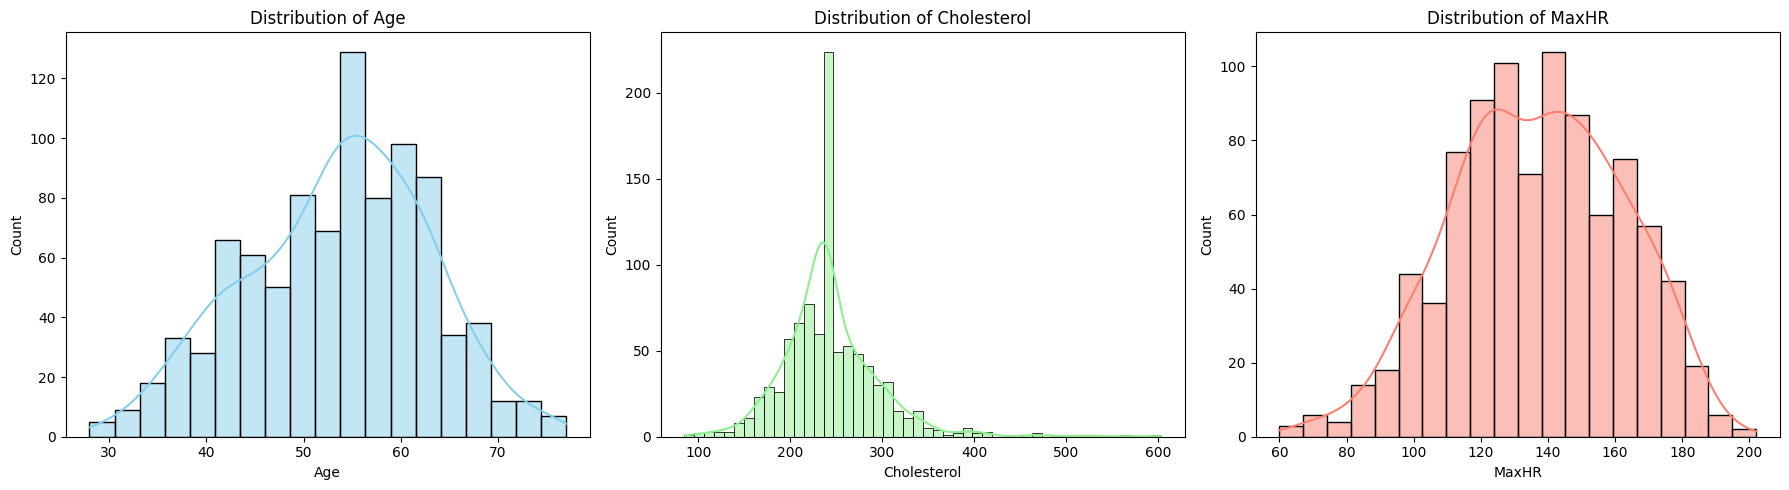

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the matplotlib figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram for Age
sns.histplot(data=df_cleaned, x='Age', kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Age')

# 2. Histogram for Cholesterol
sns.histplot(data=df_cleaned, x='Cholesterol', kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Distribution of Cholesterol')

# 3. Histogram for MaxHR
sns.histplot(data=df_cleaned, x='MaxHR', kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Distribution of MaxHR')

plt.tight_layout()
plt.show()

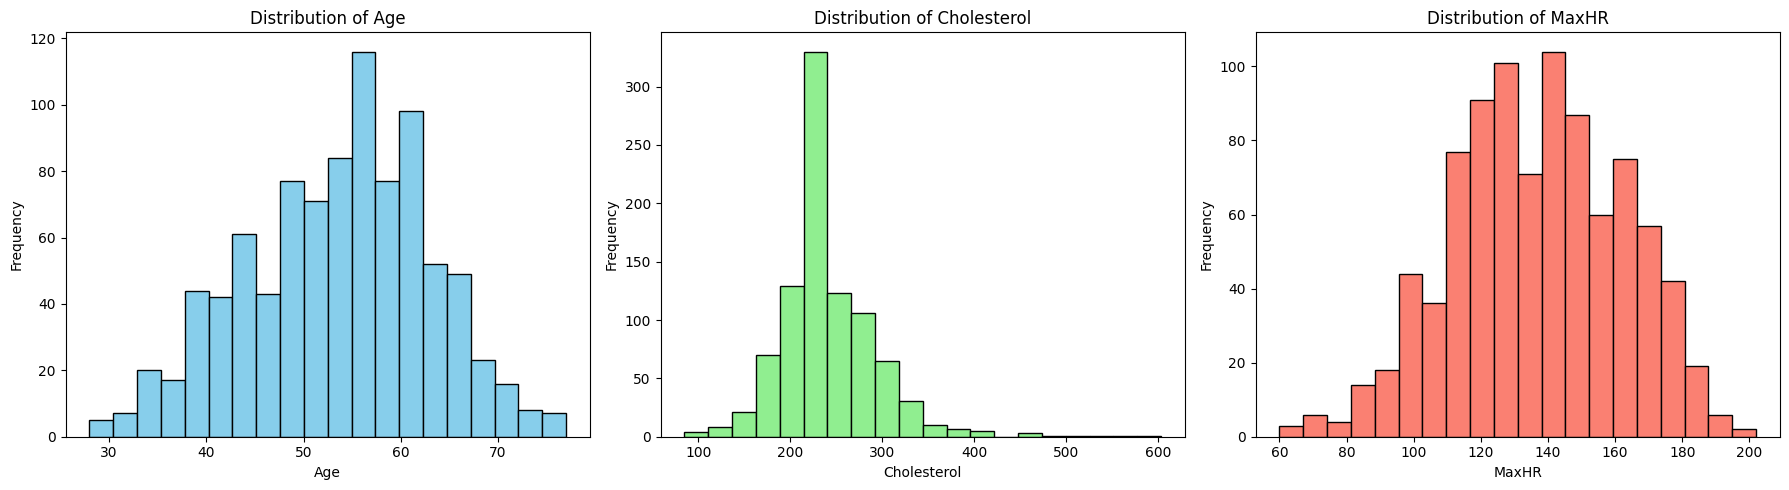

In [ ]:
import matplotlib.pyplot as plt

# Set up the matplotlib figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram for Age
df_cleaned['Age'].plot(kind='hist', bins=20, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Age')
axes[0].set_xlabel('Age')

# 2. Histogram for Cholesterol
df_cleaned['Cholesterol'].plot(kind='hist', bins=20, ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Distribution of Cholesterol')
axes[1].set_xlabel('Cholesterol')

# 3. Histogram for MaxHR
df_cleaned['MaxHR'].plot(kind='hist', bins=20, ax=axes[2], color='salmon', edgecolor='black')
axes[2].set_title('Distribution of MaxHR')
axes[2].set_xlabel('MaxHR')

plt.tight_layout()
plt.show()

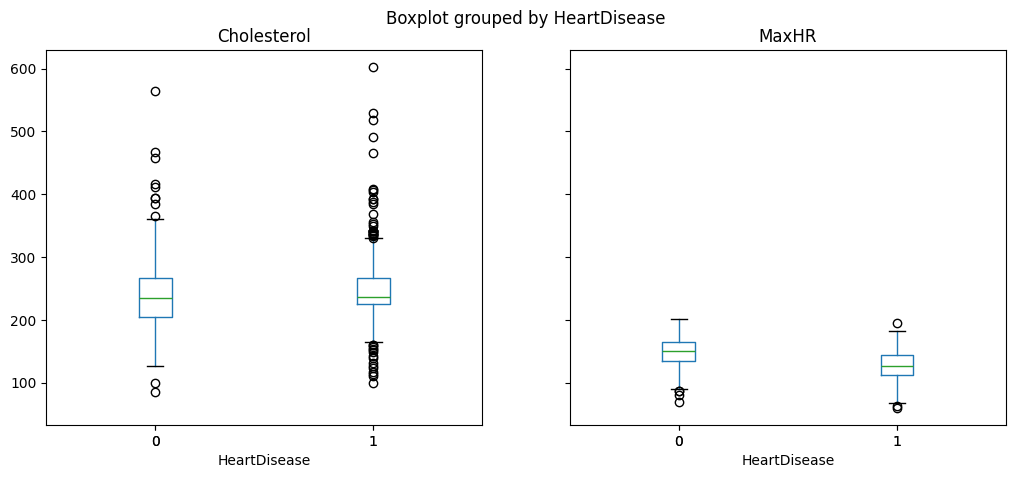

In [ ]:
import matplotlib.pyplot as plt

# Create boxplots grouped by HeartDisease
df_cleaned.boxplot(column=['Cholesterol', 'MaxHR'], by='HeartDisease', figsize=(12, 5), grid=False)

plt.show()


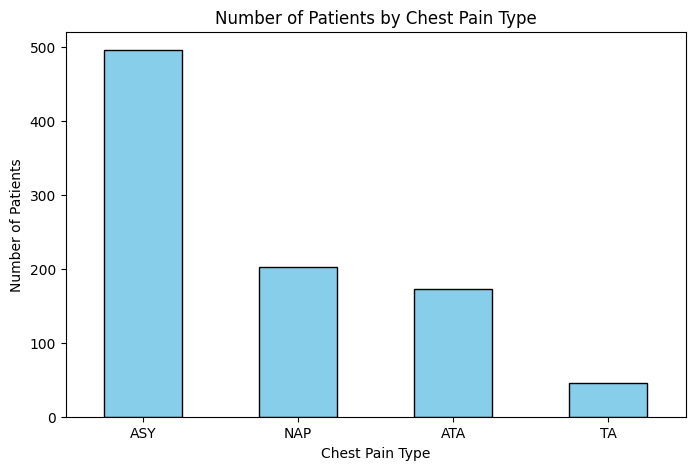

In [ ]:
import matplotlib.pyplot as plt

# Calculate the counts for each ChestPainType and create a bar chart
df_cleaned['ChestPainType'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black', figsize=(8, 5))

plt.title('Number of Patients by Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0) # Keep labels horizontal for readability
plt.show()

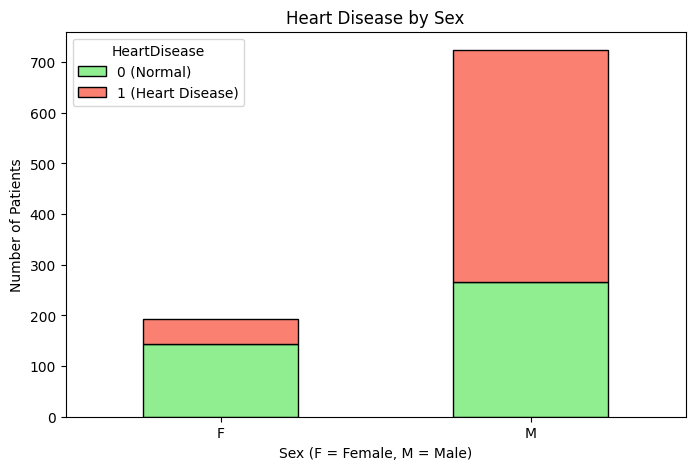

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a cross-tabulation of Sex and HeartDisease
sex_hd_crosstab = pd.crosstab(df_cleaned['Sex'], df_cleaned['HeartDisease'])

# Plot the stacked bar chart
sex_hd_crosstab.plot(kind='bar', stacked=True, color=['lightgreen', 'salmon'], edgecolor='black', figsize=(8, 5))

plt.title('Heart Disease by Sex')
plt.xlabel('Sex (F = Female, M = Male)')
plt.ylabel('Number of Patients')
plt.legend(title='HeartDisease', labels=['0 (Normal)', '1 (Heart Disease)'])
plt.xticks(rotation=0)
plt.show()

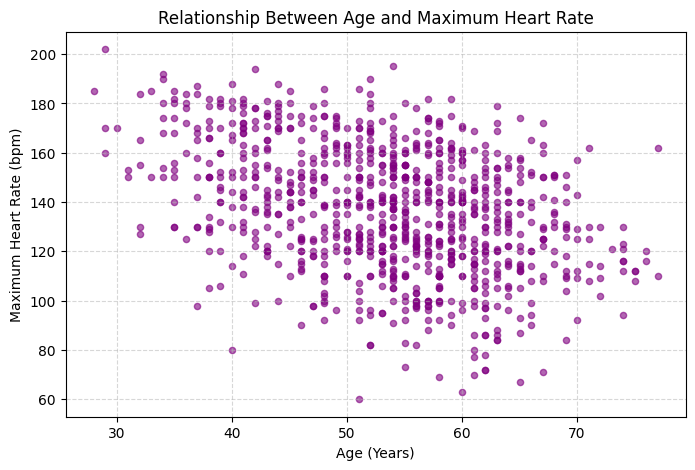

In [ ]:
import matplotlib.pyplot as plt

# Create the scatterplot
df_cleaned.plot(kind='scatter', x='Age', y='MaxHR', color='purple', alpha=0.6, figsize=(8, 5))

plt.title('Relationship Between Age and Maximum Heart Rate')
plt.xlabel('Age (Years)')
plt.ylabel('Maximum Heart Rate (bpm)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

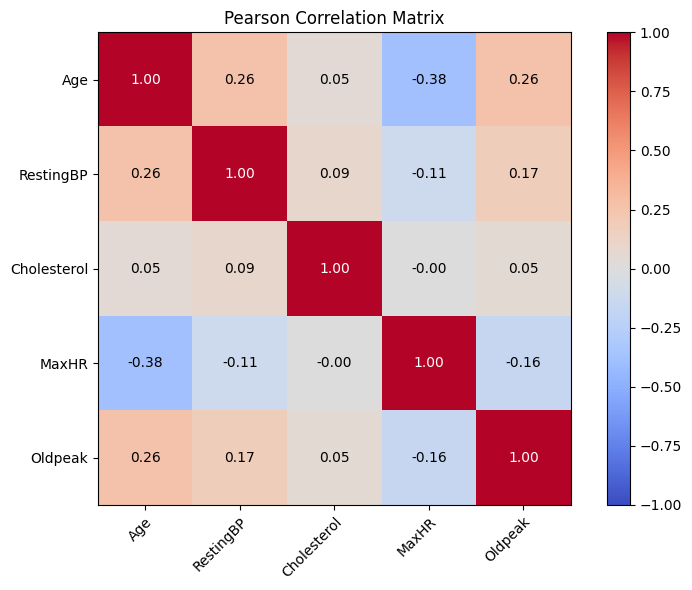

Strongest Positive Correlation: RestingBP & Age (0.263)
Strongest Negative Correlation: MaxHR & Age (-0.382)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the columns and calculate the Pearson correlation matrix
cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
corr_matrix = df_cleaned[cols].corr(method='pearson')

# Create the heatmap using only matplotlib
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# Add colorbar
fig.colorbar(cax)

# Set ticks and labels
ax.set_xticks(np.arange(len(cols)))
ax.set_yticks(np.arange(len(cols)))
ax.set_xticklabels(cols)
ax.set_yticklabels(cols)

# Rotate tick marks for x-axis
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Loop over data dimensions and create text annotations
for i in range(len(cols)):
    for j in range(len(cols)):
        text = ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                       ha="center", va="center", color="black" if abs(corr_matrix.iloc[i, j]) < 0.5 else "white")

ax.set_title('Pearson Correlation Matrix')
fig.tight_layout()
plt.show()

# Programmatically identify strongest positive and negative correlations
# Extract upper triangle to avoid duplicates and self-correlations (1.0)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
correlations = upper_tri.unstack().dropna()

strongest_pos_pair = correlations.idxmax()
strongest_pos_val = correlations.max()

strongest_neg_pair = correlations.idxmin()
strongest_neg_val = correlations.min()

print(f"Strongest Positive Correlation: {strongest_pos_pair[0]} & {strongest_pos_pair[1]} ({strongest_pos_val:.3f})")
print(f"Strongest Negative Correlation: {strongest_neg_pair[0]} & {strongest_neg_pair[1]} ({strongest_neg_val:.3f})")


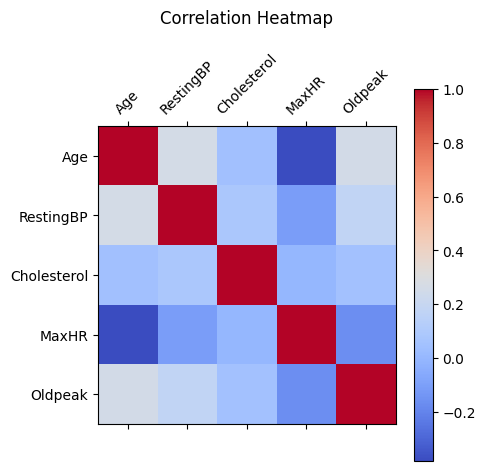

Strongest Positive Correlation:
Age  RestingBP    0.263084
dtype: float64

Strongest Negative Correlation:
Age  MaxHR   -0.38228
dtype: float64


In [ ]:
import matplotlib.pyplot as plt

# 1. Calculate the correlation matrix
cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
corr_matrix = df_cleaned[cols].corr()

# 2. Create a simple heatmap
plt.matshow(corr_matrix, cmap='coolwarm')
plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)
plt.colorbar()
plt.title('Correlation Heatmap', pad=20)
plt.show()

# 3. Identify the strongest correlations programmatically
# Unstack the matrix into pairs and remove the 1.0 self-correlations
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs != 1.0]

print("Strongest Positive Correlation:")
print(corr_pairs.nlargest(1))

print("\nStrongest Negative Correlation:")
print(corr_pairs.nsmallest(1))

In [ ]:
# 1. Construct the contingency table
contingency_table = pd.crosstab(df_cleaned['ChestPainType'], df_cleaned['HeartDisease'], margins=True, margins_name='Total')

print("--- Contingency Table ---")
display(contingency_table)

# 2. Calculate the percentage of heart disease (HeartDisease=1) for each type
# normalize='index' calculates percentages across the rows
pct_table = pd.crosstab(df_cleaned['ChestPainType'], df_cleaned['HeartDisease'], normalize='index') * 100

print("\n--- Percentage Distribution ---")
display(pct_table.round(2).astype(str) + '%')

--- Contingency Table ---


HeartDisease,0,1,Total
ChestPainType,,,
ASY,104,392,496
ATA,149,24,173
NAP,131,71,202
TA,26,20,46
Total,410,507,917



--- Percentage Distribution ---


HeartDisease,0,1
ChestPainType,,
ASY,20.97%,79.03%
ATA,86.13%,13.87%
NAP,64.85%,35.15%
TA,56.52%,43.48%


In [ ]:
from scipy.stats import chi2_contingency

# 1. Create the contingency table
contingency = pd.crosstab(df_cleaned['Sex'], df_cleaned['HeartDisease'])

# 2. Perform the Chi-square test
chi2_stat, p_val, dof, expected = chi2_contingency(contingency)

print(f"Chi-square Test Statistic: {chi2_stat:.2f}")
print(f"p-value: {p_val:.2e}")

Chi-square Test Statistic: 83.87
p-value: 5.28e-20


In [ ]:
from scipy.stats import ttest_ind

# Separate the age data into two groups based on HeartDisease status
age_hd1 = df_cleaned[df_cleaned['HeartDisease'] == 1]['Age']
age_hd0 = df_cleaned[df_cleaned['HeartDisease'] == 0]['Age']

# Calculate the mean age for each group
mean_age_hd1 = age_hd1.mean()
mean_age_hd0 = age_hd0.mean()

print(f"Mean Age of patients with Heart Disease (1): {mean_age_hd1:.2f} years")
print(f"Mean Age of patients without Heart Disease (0): {mean_age_hd0:.2f} years")

# Perform the independent samples t-test
# Using equal_var=False (Welch's t-test) is generally safer when sample sizes or variances might differ
t_stat, p_val = ttest_ind(age_hd1, age_hd0, equal_var=False)

print(f"\nT-statistic: {t_stat:.2f}")
print(f"p-value: {p_val:.2e}")

Mean Age of patients with Heart Disease (1): 55.90 years
Mean Age of patients without Heart Disease (0): 50.55 years

T-statistic: 8.82
p-value: 6.56e-18


In [ ]:
from scipy.stats import ttest_ind

# Separate the cholesterol data by Sex
chol_m = df_cleaned[df_cleaned['Sex'] == 'M']['Cholesterol']
chol_f = df_cleaned[df_cleaned['Sex'] == 'F']['Cholesterol']

# Calculate means
mean_chol_m = chol_m.mean()
mean_chol_f = chol_f.mean()

print(f"Mean Cholesterol (Male): {mean_chol_m:.2f} mg/dl")
print(f"Mean Cholesterol (Female): {mean_chol_f:.2f} mg/dl")

# Perform Welch's t-test (equal_var=False) to account for different sample sizes
t_stat, p_val = ttest_ind(chol_m, chol_f, equal_var=False)

print(f"\nT-statistic: {t_stat:.2f}")
print(f"p-value: {p_val:.4f}")

Mean Cholesterol (Male): 240.15 mg/dl
Mean Cholesterol (Female): 254.70 mg/dl

T-statistic: -3.04
p-value: 0.0026


In [ ]:
from scipy.stats import linregress

# 1. Predict MaxHR from Age
res_hr = linregress(df_cleaned['Age'], df_cleaned['MaxHR'])
r_squared_hr = res_hr.rvalue**2

print(f"--- 1. MaxHR from Age ---")
print(f"Regression Equation: MaxHR = {res_hr.intercept:.2f} + ({res_hr.slope:.2f} * Age)")
print(f"Slope (b): {res_hr.slope:.2f}")
print(f"Intercept (a): {res_hr.intercept:.2f}")
print(f"R-squared: {r_squared_hr:.4f}")

# 2. Predict Cholesterol from RestingBP
res_chol = linregress(df_cleaned['RestingBP'], df_cleaned['Cholesterol'])
r_squared_chol = res_chol.rvalue**2

print(f"\n--- 2. Cholesterol from RestingBP ---")
print(f"Regression Equation: Cholesterol = {res_chol.intercept:.2f} + ({res_chol.slope:.2f} * RestingBP)")
print(f"Slope (b): {res_chol.slope:.2f}")
print(f"R-squared: {r_squared_chol:.4f}")

--- 1. MaxHR from Age ---
Regression Equation: MaxHR = 191.99 + (-1.03 * Age)
Slope (b): -1.03
Intercept (a): 191.99
R-squared: 0.1461

--- 2. Cholesterol from RestingBP ---
Regression Equation: Cholesterol = 209.35 + (0.26 * RestingBP)
Slope (b): 0.26
R-squared: 0.0074


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Define the independent variables (X) and the dependent variable (y)
X = df_cleaned[['Age', 'RestingBP', 'Cholesterol']]
y = df_cleaned['Oldpeak']

# Initialize and fit the Multiple Linear Regression model
model = LinearRegression()
model.fit(X, y)

# Extract and print the metrics
intercept = model.intercept_
coefficients = model.coef_
r_squared = model.score(X, y)

print("--- Multiple Linear Regression Results ---")
print(f"Intercept: {intercept:.4f}")
print(f"Coefficient for Age: {coefficients[0]:.4f}")
print(f"Coefficient for RestingBP: {coefficients[1]:.4f}")
print(f"Coefficient for Cholesterol: {coefficients[2]:.4f}")
print(f"R-squared: {r_squared:.4f}")

--- Multiple Linear Regression Results ---
Intercept: -1.5338
Coefficient for Age: 0.0257
Coefficient for RestingBP: 0.0066
Coefficient for Cholesterol: 0.0007
R-squared: 0.0802


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, accuracy_score

# 1. Load and clean data
df = pd.read_csv('heart_disease_data.csv')
df_cleaned = df[df['RestingBP'] > 0].copy()
median_chol = df_cleaned.loc[df_cleaned['Cholesterol'] > 0, 'Cholesterol'].median()
df_cleaned.loc[df_cleaned['Cholesterol'] == 0, 'Cholesterol'] = median_chol

# 2. Select variables
features = ['Age', 'Sex', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak',
            'ChestPainType', 'ExerciseAngina', 'ST_Slope']
X = df_cleaned[features]
y = df_cleaned['HeartDisease']

# 3. Create dummy variables for categorical features (drop_first avoids multicollinearity)
X_encoded = pd.get_dummies(X, drop_first=True).astype(float)
X_encoded = sm.add_constant(X_encoded) # Add intercept

# 4. (a) Fit the logistic regression model
logit_model = sm.Logit(y, X_encoded)
result = logit_model.fit()
print(result.summary())

# 5. (c) Calculate Odds Ratios
print("\n--- Odds Ratios ---")
print(np.exp(result.params))

# 6. (d) Confusion Matrix & (e) Accuracy
predictions_prob = result.predict(X_encoded)
predictions_binary = (predictions_prob >= 0.5).astype(int)

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y, predictions_binary))
print(f"\nAccuracy: {accuracy_score(y, predictions_binary):.4f}")

Optimization terminated successfully.
         Current function value: 0.346007
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           HeartDisease   No. Observations:                  917
Model:                          Logit   Df Residuals:                      904
Method:                           MLE   Df Model:                           12
Date:                Sun, 20 Sep 2026   Pseudo R-squ.:                  0.4967
Time:                        16:05:54   Log-Likelihood:                -317.29
converged:                       True   LL-Null:                       -630.48
Covariance Type:            nonrobust   LLR p-value:                2.461e-126
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.9013      1.356     -1.402      0.161      -4.560       0.757
Age     